# ARTI406 – Assignment 2: Data Quality Assessment & Preprocessing

**Dataset:** Chocolate Sales  
**Source:** Kaggle – Chocolate Sales Dataset  
**Description:** A sales dataset recording chocolate transactions across 6 countries, covering sales persons, products, transaction dates, revenue amounts, and boxes shipped.

---

## Dataset Overview

| Column | Description |
|---|---|
| Sales Person | Name of the sales representative |
| Country | Country where the sale occurred |
| Product | Chocolate product sold |
| Date | Date of the transaction |
| Amount | Revenue from the sale (originally stored as a dollar string) |
| Boxes Shipped | Number of boxes shipped per transaction |

> **Dataset size:** 3,282 rows × 6 columns  
> **Time range:** January 2022 – August 2024

---

![step2.png](img/step2.png)

## 1. Load Dataset

We begin by importing the required libraries and loading our dataset.

In [7]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [6]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Load Dataset
pd.set_option("display.max_columns", None)

df = pd.read_csv("Chocolate_Sales.csv")
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (3282, 6)


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184
5,Van Tuxwell,India,Smooth Sliky Salty,06/06/2022,"$5,376.00",38
6,Oby Sorrel,UK,99% Dark & Pure,25/01/2022,"$13,685.00",176
7,Gunar Cockshoot,Australia,After Nines,24/03/2022,"$3,080.00",73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,20/04/2022,"$3,990.00",59
9,Brien Boise,Australia,99% Dark & Pure,04/07/2022,"$2,835.00",102


## 2. Data Quality Assessment

### 2.1 Check Data Types

Data types must match the real meaning of each column. For example:
- `Date` should be `datetime`
- `Amount` should be numeric (float)
- `Boxes Shipped` should be integer

In [9]:
df.dtypes

Sales Person       str
Country            str
Product            str
Date               str
Amount             str
Boxes Shipped    int64
dtype: object

We observe that:
- `Date` is stored as `object` (string) — needs to be converted to `datetime`
- `Amount` is stored as `object` (string with `$` and `,`) — needs to be cleaned and converted to `float`

Incorrect data types will prevent time-based analysis and numerical calculations.

### 2.2 Convert Incorrect Data Types

We will:
1. Convert `Date` to `datetime` format  
2. Strip currency symbols from `Amount` and convert to `float`

In [10]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Strip currency symbols and convert Amount to float
df['Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True)
df['Amount'] = pd.to_numeric(df['Amount'])

df.dtypes

Sales Person                str
Country                     str
Product                     str
Date             datetime64[us]
Amount                  float64
Boxes Shipped             int64
dtype: object

✅ `Date` is now stored as `datetime64[ns]`  
✅ `Amount` is now stored as `float64`  

This enables correct time-based grouping and accurate numerical calculations.

## 3. Handling Missing Values

### 3.1 Detect Missing Values

Missing values reduce data quality and can negatively affect model performance.

In [11]:
df.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

The dataset has **no missing values** in its original form.  
To practice preprocessing techniques, we will **artificially introduce** missing values.

### 3.2 Introduce Artificial Missing Values (for Learning Purposes)

We simulate missing data by setting rows 0–5 of the `Amount` column to `NaN`.

- `df_missing.loc[0:5, 'Amount'] = np.nan` — selects rows 0 to 5 (inclusive) and replaces the `Amount` values with `NaN`
- `np.nan` is the standard representation for missing numeric values in pandas

In [12]:
df_missing = df.copy()
df_missing.loc[0:5, 'Amount'] = np.nan
df_missing.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           6
Boxes Shipped    0
dtype: int64

In [13]:
print("Original shape:            ", df.shape)
print("After removing some values:", df_missing.shape)

Original shape:             (3282, 6)
After removing some values: (3282, 6)


In [14]:
df_missing.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,NaN,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,NaN,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,NaN,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,NaN,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,NaN,184
5,Van Tuxwell,India,Smooth Sliky Salty,2022-06-06,NaN,38
6,Oby Sorrel,UK,99% Dark & Pure,2022-01-25,13685.0,176
7,Gunar Cockshoot,Australia,After Nines,2022-03-24,3080.0,73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,2022-04-20,3990.0,59
9,Brien Boise,Australia,99% Dark & Pure,2022-07-04,2835.0,102


### Strategy 1: Remove Records

This strategy drops all rows that contain missing values.  
It is suitable when the proportion of missing data is small.

In [15]:
df_removed = df_missing.dropna()
print("Shape after dropping NaN rows:", df_removed.shape)
df_removed.isna().sum()

Shape after dropping NaN rows: (3276, 6)


Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

The dataset now has fewer rows.  
This method is simple but loses information.  
Removing too many rows can reduce model quality.

### Strategy 2: Mean Imputation

![Mean.png](img/Mean.png)

The **mean** is the sum of all values divided by the total count.  
It is effective for normally distributed data without extreme outliers.

In [16]:
df_missing.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,NaN,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,NaN,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,NaN,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,NaN,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,NaN,184
5,Van Tuxwell,India,Smooth Sliky Salty,2022-06-06,NaN,38
6,Oby Sorrel,UK,99% Dark & Pure,2022-01-25,13685.0,176
7,Gunar Cockshoot,Australia,After Nines,2022-03-24,3080.0,73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,2022-04-20,3990.0,59
9,Brien Boise,Australia,99% Dark & Pure,2022-07-04,2835.0,102


In [17]:
df_imputed_mean = df_missing.copy()

mean_value = df_imputed_mean['Amount'].mean()
print(f"Mean value used for imputation: {mean_value:.2f}")

df_imputed_mean['Amount'] = df_imputed_mean['Amount'].fillna(mean_value)
df_imputed_mean.isna().sum()

Mean value used for imputation: 6026.27


Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [18]:
df_imputed_mean.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,6026.272241,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,6026.272241,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,6026.272241,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,6026.272241,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,6026.272241,184
5,Van Tuxwell,India,Smooth Sliky Salty,2022-06-06,6026.272241,38
6,Oby Sorrel,UK,99% Dark & Pure,2022-01-25,13685.000000,176
7,Gunar Cockshoot,Australia,After Nines,2022-03-24,3080.000000,73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,2022-04-20,3990.000000,59
9,Brien Boise,Australia,99% Dark & Pure,2022-07-04,2835.000000,102


✅ Missing values are now replaced with the **average Amount**.  
This preserves dataset size, but may reduce variability and is sensitive to outliers.

### Strategy 3: Median Imputation

![median_formula_2.png](img/median_formula_2.png)

The **median** is the middle value when data is sorted in order.  
It is more robust than the mean, especially when the data is skewed or contains outliers.

In [19]:
df_imputed_median = df_missing.copy()

median_value = df_imputed_median['Amount'].median()
print(f"Median value used for imputation: {median_value:.2f}")

df_imputed_median['Amount'] = df_imputed_median['Amount'].fillna(median_value)
df_imputed_median.isna().sum()

Median value used for imputation: 5220.74


Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [20]:
df_imputed_median.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5220.745,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,5220.745,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,5220.745,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,5220.745,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,5220.745,184
5,Van Tuxwell,India,Smooth Sliky Salty,2022-06-06,5220.745,38
6,Oby Sorrel,UK,99% Dark & Pure,2022-01-25,13685.000,176
7,Gunar Cockshoot,Australia,After Nines,2022-03-24,3080.000,73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,2022-04-20,3990.000,59
9,Brien Boise,Australia,99% Dark & Pure,2022-07-04,2835.000,102


✅ Missing values are replaced with the **median Amount**.  
This approach is safer when the data contains extreme values.

## 4. Handling Outliers

Outliers are extreme values that can distort model predictions.  
We will detect outliers using the **IQR (Interquartile Range)** method.

![IQR.png](img/IQR.png)

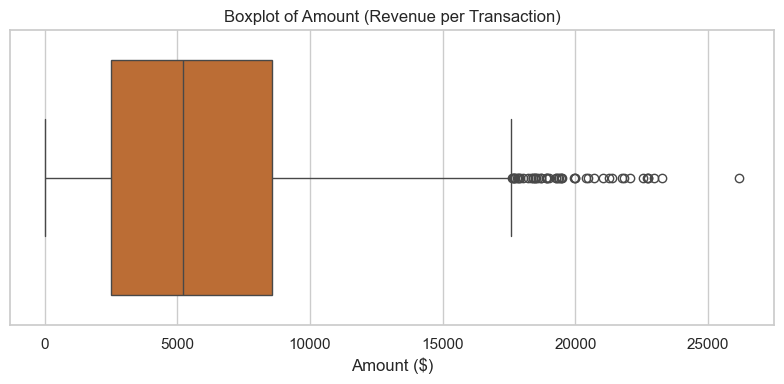

In [21]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Amount'], color="chocolate")
plt.title("Boxplot of Amount (Revenue per Transaction)")
plt.xlabel("Amount ($)")
plt.tight_layout()
plt.show()

Points outside the whiskers represent potential **outliers**.  
These extreme revenue values may influence model predictions disproportionately.

### Detect Outliers Using IQR

The IQR method defines outliers as values outside:

- **Lower bound:** Q1 − 1.5 × IQR  
- **Upper bound:** Q3 + 1.5 × IQR

In [22]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower:.2f}")
print(f"Upper Bound: {upper:.2f}")

outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]
print(f"\nNumber of outliers detected: {len(outliers)}")
outliers.head(15)

Q1: 2521.49
Q3: 8556.84
IQR: 6035.35
Lower Bound: -6531.53
Upper Bound: 17609.86

Number of outliers detected: 50


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
66,Van Tuxwell,Australia,Organic Choco Syrup,2022-08-10,19453.00,14
135,Van Tuxwell,India,Organic Choco Syrup,2022-05-16,19929.00,174
212,Marney O'Breen,UK,Smooth Sliky Salty,2022-05-13,18991.00,88
434,Jan Morforth,New Zealand,Mint Chip Choco,2022-06-30,18340.00,285
543,Ches Bonnell,India,Peanut Butter Cubes,2022-01-27,22050.00,208
589,Curtice Advani,India,Smooth Sliky Salty,2022-04-19,19327.00,135
609,Jan Morforth,Australia,Mint Chip Choco,2022-02-22,17626.00,103
751,Rafaelita Blaksland,New Zealand,Eclairs,2022-02-07,19481.00,51
806,Brien Boise,India,85% Dark Bars,2022-08-09,18032.00,205
1008,Kaine Padly,UK,After Nines,2022-01-21,18697.00,176


The output displays records considered extreme based on statistical boundaries.  
These may be valid high-value transactions or potential data errors.

### Remove Outliers

We remove all records whose `Amount` falls outside the acceptable IQR range.

In [23]:
df_no_outliers = df[(df['Amount'] >= lower) & (df['Amount'] <= upper)]
print("Original shape:          ", df.shape)
print("After removing outliers: ", df_no_outliers.shape)

Original shape:           (3282, 6)
After removing outliers:  (3232, 6)


> ⚠️ **Important Note:**  
> Not all outliers are errors. A very large transaction might represent a valid bulk corporate order.  
> Before removing outliers, always ask:  
> - Is this value a data entry mistake?  
> - Or is it a valid but rare observation?

### Capping Outliers (Percentile Method)

Instead of removing outliers, we **cap** extreme values at the 5th and 95th percentiles.

![percentile.png](img/percentile.png)

In [24]:
lower_cap = df['Amount'].quantile(0.05)
upper_cap = df['Amount'].quantile(0.95)

print(f"Lower cap (5th percentile):  {lower_cap:.2f}")
print(f"Upper cap (95th percentile): {upper_cap:.2f}")

df_capped = df.copy()
df_capped['Amount'] = df_capped['Amount'].clip(lower_cap, upper_cap)

print(f"\nOriginal Amount range: {df['Amount'].min():.2f} – {df['Amount'].max():.2f}")
print(f"Capped   Amount range: {df_capped['Amount'].min():.2f} – {df_capped['Amount'].max():.2f}")

Lower cap (5th percentile):  522.12
Upper cap (95th percentile): 14686.90

Original Amount range: 7.00 – 26170.95
Capped   Amount range: 522.12 – 14686.90


## 5. Data Transformation – Normalization

Normalization **scales numerical features** to a comparable range, ensuring no single feature dominates model calculations due to its magnitude.

### Min-Max Normalization

Min-Max normalization rescales values to the range **[0, 1]** using the formula:

![min_max.png](img/min_max.png)

This method:
- Preserves the original distribution shape
- Is especially useful for distance-based models (KNN, K-Means, SVM)

In [25]:
df[['Amount', 'Boxes Shipped']].describe()

,Amount,Boxes Shipped
count,3282.000000,3282.000000
mean,6030.338775,164.666971
std,4393.980200,124.024736
min,7.000000,1.000000
25%,2521.495000,71.000000
50%,5225.500000,137.000000
75%,8556.842500,232.000000
max,26170.950000,778.000000


In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Amount', 'Boxes Shipped']].copy()

df_scaled[['Amount', 'Boxes Shipped']] = scaler.fit_transform(df_scaled)

print("Scaled value ranges:")
print(df_scaled.describe().loc[['min', 'max']])
df_scaled.head(10)

Scaled value ranges:
     Amount  Boxes Shipped
min     0.0            0.0
max     1.0            1.0


,Amount,Boxes Shipped
0,0.203066,0.230373
1,0.301522,0.119691
2,0.171763,0.115830
3,0.486127,0.438867
4,0.522780,0.235521
5,0.205206,0.047619
6,0.522780,0.225225
7,0.117452,0.092664
8,0.152232,0.074646
9,0.108088,0.129987


In [31]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 4.6 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.3 MB 11.6 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 19.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 13.8 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ All numerical values are now scaled to the range **[0, 1]**.  
- The minimum value in each column becomes `0`  
- The maximum value becomes `1`  
- All other values are proportionally mapped in between  

Normalization does **NOT** change the relative ordering of data points.

## 6. Exploratory Data Analysis (EDA)

Beyond preprocessing, we explore the dataset visually to identify patterns and trends.

C:\Users\User\AppData\Local\Temp\ipykernel_24060\487764031.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sales.index, y=country_sales.values, palette="YlOrBr")


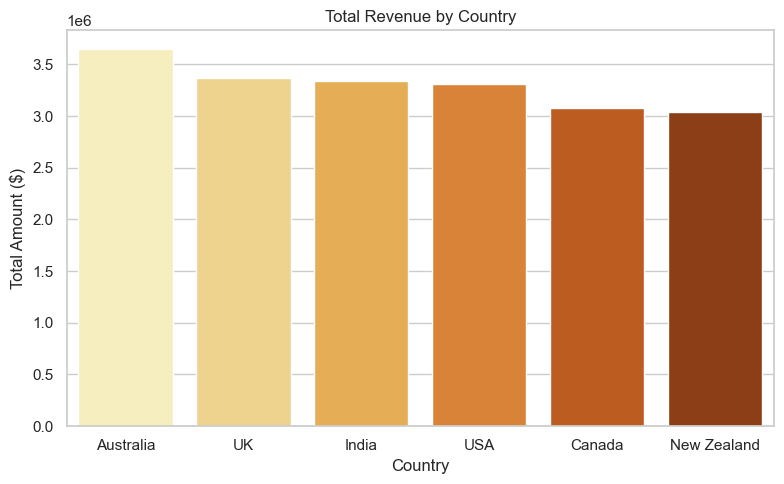

In [33]:
# Total Revenue by Country
country_sales = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=country_sales.index, y=country_sales.values, palette="YlOrBr")
plt.title("Total Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Total Amount ($)")
plt.tight_layout()
plt.show()

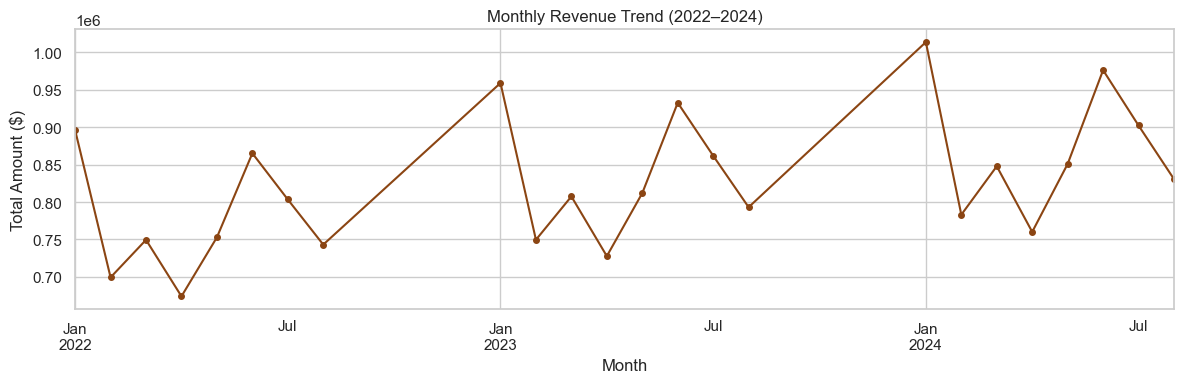

In [34]:
# Monthly Revenue Trend
df['Month'] = df['Date'].dt.to_period('M')
monthly = df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(12, 4))
monthly.plot(kind='line', color='saddlebrown', marker='o', markersize=4)
plt.title("Monthly Revenue Trend (2022–2024)")
plt.xlabel("Month")
plt.ylabel("Total Amount ($)")
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_24060\4159750287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="copper")


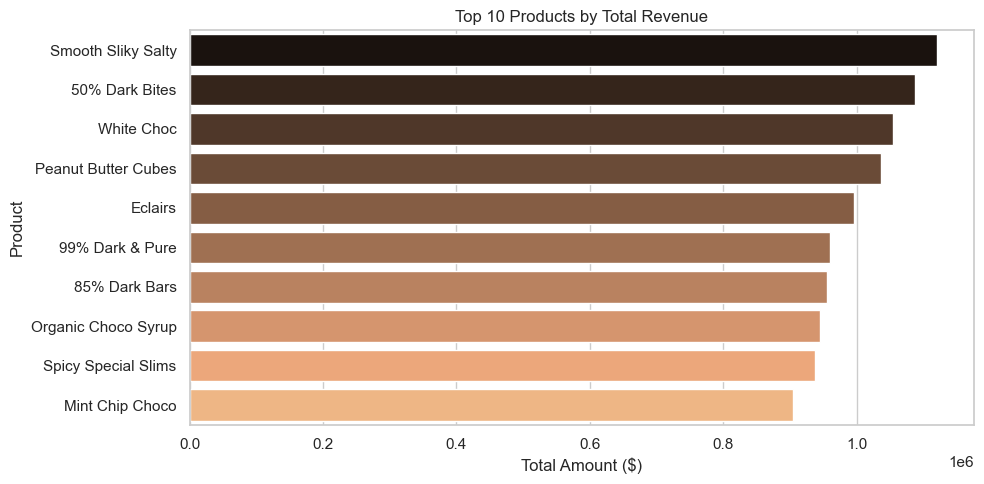

In [35]:
# Top 10 Products by Revenue
top_products = df.groupby('Product')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.values, y=top_products.index, palette="copper")
plt.title("Top 10 Products by Total Revenue")
plt.xlabel("Total Amount ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## 7. Summary

| Step | Technique Applied | Purpose |
|---|---|---|
| Data Loading | `pd.read_csv()` | Load raw dataset |
| Type Conversion | `pd.to_datetime()`, `pd.to_numeric()` | Fix incorrect data types |
| Missing Values | Drop / Mean / Median Imputation | Handle incomplete data |
| Outlier Detection | IQR Method | Identify extreme values |
| Outlier Handling | Removal & Capping | Reduce distortion |
| Normalization | Min-Max Scaler | Scale features to [0, 1] |
| EDA | Bar charts, Line plots | Discover patterns |

---
*ARTI406 – Assignment 2 | Chocolate Sales Dataset*